# Manifold reconstruction of mice hippocampus LFP

In [1]:
# import sys
# sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [2]:
import numpy as np
import mne
import os
import ripser
from concurrent.futures import ThreadPoolExecutor
from scipy import signal
from scipy.signal import hilbert, butter, filtfilt, spectrogram
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import acf
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from NeuralFieldManifold.models import AR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

set_pub_style()

/home/potato/miniconda3/envs/manifold/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def bandpass_filter(x, Fs, low, high, order=4):
    wn = [low/(Fs/2), high/(Fs/2)]
    sos = signal.butter(order, wn, btype='bandpass', output='sos')
    return signal.sosfiltfilt(sos, x)

def envelope_normalize(x, fs, fband=(15, 30), env_lp_hz=5.0, eps=1e-6):
    b, a = signal.butter(4, np.array(fband)/(fs/2), btype='bandpass')
    x_bp = signal.filtfilt(b, a, x)
    z = hilbert(x_bp)
    A = np.abs(z)
    if env_lp_hz is not None:
        b_lp, a_lp = signal.butter(2, env_lp_hz/(fs/2), btype='low')
        A = signal.filtfilt(b_lp, a_lp, A)
    x_flat = x_bp / (A + eps)
    x_flat *= np.median(A)
    return x_flat, x_bp, A

def process_signal(LFP, chan, Fs, time_window, 
                   notch_freq=50, notch_Q=30,
                   bandpass_low=80, bandpass_high=140,
                   fband=(1, 80), env_lp_hz=3.0,
                   target_Fs=500):
    """Process LFP signal with notch filter, bandpass, envelope normalization, and downsampling."""
    filtered = signal.filtfilt(*signal.iirnotch(notch_freq, notch_Q, Fs), LFP[time_window, chan])
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    
    # Downsample if needed (before envelope normalization for efficiency)
    if Fs > target_Fs:
        r = int(np.floor(Fs / target_Fs))
        xs_raw = signal.decimate(xs_raw, r, ftype='iir', zero_phase=True).astype(float)
        Fs_out = Fs / r
    else:
        Fs_out = Fs
    
    xs, _, _ = envelope_normalize(xs_raw, Fs_out, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw, Fs_out


def fit_ar_model(xs, Fs, p=4, train_frac=0.9, refresh_every=10):
    X, y = AR.lag_matrix(xs, p)
    ntr = int(train_frac * len(y))
    X_tr, y_tr = X[:ntr], y[:ntr]
    w = AR.fit(X_tr, y_tr)
    N_te = len(y) - ntr
    t0 = p + ntr
    true_test = xs[t0 : t0 + N_te]
    yhat_ctrl = AR.hybrid_predict(xs, w, p, start_idx=t0, n_steps=N_te, refresh_every=refresh_every)
    full_pred = AR.hybrid_predict(xs, w, p, start_idx=p, n_steps=len(xs)-p, refresh_every=refresh_every)
    xs_pred_full = np.concatenate([xs[:p], full_pred])
    mse, mae, corr = AR.metrics(true_test, yhat_ctrl)
    return {
        'w': w, 'p': p, 'ntr': ntr, 'y': y, 'true_test': true_test,
        'yhat_ctrl': yhat_ctrl, 'xs_pred_full': xs_pred_full, 't0': t0,
        'mse': mse, 'mae': mae, 'corr': corr, 'refresh_every': refresh_every
    }

In [4]:
filename = 'data/eke003_spont_250818_175844.npy'
channel_id = 1
raw_lfp = np.load(filename)[channel_id]
fs_original = 20000

print(f"Loaded LFP: {raw_lfp.shape} samples at {fs_original} Hz")

Loaded LFP: (10841760,) samples at 20000 Hz


In [5]:
snippet_sec = 5
time_window = np.arange(int(snippet_sec * fs_original))

# Reshape raw_lfp to (samples, channels) format for process_signal
LFP = raw_lfp.reshape(-1, 1)

xs, xs_raw, Fs = process_signal(LFP, chan=0, Fs=fs_original, time_window=time_window,
                                 bandpass_low=1, bandpass_high=20,
                                 fband=(1, 80), env_lp_hz=3.0,
                                 target_Fs=500)

time = np.arange(len(xs)) / Fs
print(f"Processed signal: {len(xs)} samples at {Fs} Hz")

Processed signal: 2500 samples at 500.0 Hz


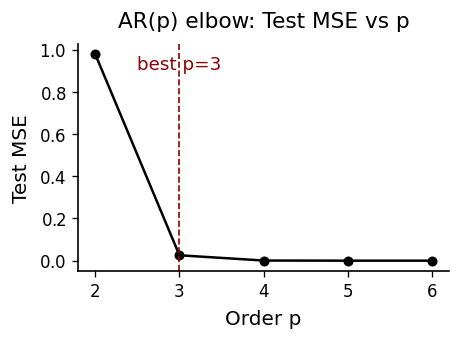

In [6]:
# Sweep AR orders for elbow plot
p_list = list(range(2, 7))
mse_te_list = []
for p in p_list:
    X, y_temp = AR.lag_matrix(xs, p)
    ntr_temp = int(0.1 * len(y_temp))
    X_tr, y_tr = X[:ntr_temp], y_temp[:ntr_temp]
    X_te, y_te = X[ntr_temp:], y_temp[ntr_temp:]
    w_temp = AR.fit(X_tr, y_tr)
    yhat_te = AR.predict_from_params(X_te, w_temp)
    mse_te, _, _ = AR.metrics(y_te, yhat_te)
    mse_te_list.append(mse_te)

best_p_by_mse = p_list[int(np.argmin(mse_te_list))]

def plot_mse_elbow(p_list, mse_list, best_p, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(p_list, mse_list, marker='o', color=color_main, lw=1.5, ms=5)
    ax.axvline(best_p, linestyle='--', color=color_alt, linewidth=1)
    ax.text(best_p, ax.get_ylim()[1]*0.95, f"best p={best_p}", ha='center', va='top', color=color_alt, fontsize=11)
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(sf)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 3))
    ax.yaxis.get_offset_text().set_size(10)
    prettify(ax, title="AR(p) elbow: Test MSE vs p", xlabel="Order p", ylabel="Test MSE")
    plt.tight_layout()
    plt.show()

best_p_by_mse = 3

plot_mse_elbow(p_list, mse_te_list, best_p_by_mse)

In [7]:
ar_results = fit_ar_model(xs, Fs, p=3, train_frac=0.1, refresh_every=10)

w = ar_results['w']
p_use = ar_results['p']
ntr = ar_results['ntr']
y = ar_results['y']
true_test = ar_results['true_test']
yhat_ctrl = ar_results['yhat_ctrl']
xs_pred_full = ar_results['xs_pred_full']
REFRESH_EVERY = ar_results['refresh_every']

print(f"AR({p_use}): MSE={ar_results['mse']:.6f}, corr={ar_results['corr']:.3f}")

AR(3): MSE=192.180213, corr=0.990


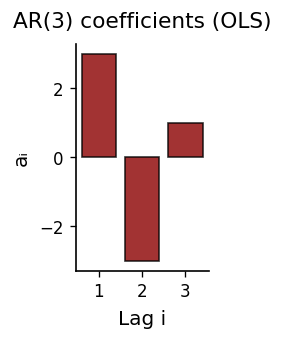

In [8]:
def plot_ar_coefficients(w, p, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(2, 3))
    ax.bar(np.arange(1, p+1), w[1:], color=color_alt, edgecolor=color_main, alpha=0.8)
    prettify(ax, title=f"AR({p}) coefficients (OLS)", xlabel="Lag i", ylabel="aᵢ")
    plt.tight_layout()
    plt.show()

plot_ar_coefficients(w, p_use)

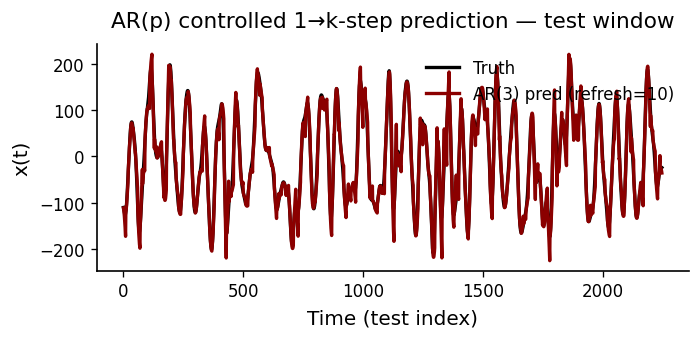

In [9]:
def plot_prediction(y_true, y_pred, p, refresh, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(y_true + 1, color=color_main, lw=2, label="Truth")
    ax.plot(y_pred, color=color_alt, lw=2, label=f"AR({p}) pred (refresh={refresh})")
    prettify(ax, title="AR(p) controlled 1→k-step prediction — test window",
             xlabel="Time (test index)", ylabel="x(t)", add_legend=True)
    plt.tight_layout()
    plt.show()

plot_prediction(y[ntr:], yhat_ctrl, p_use, REFRESH_EVERY)

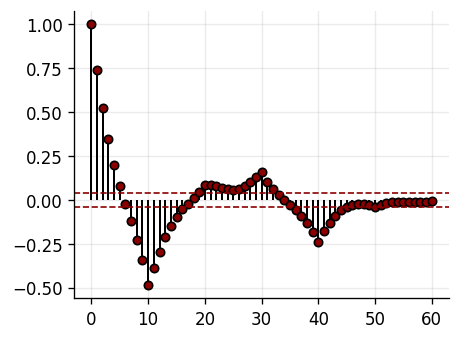

In [10]:
def plot_residual_acf(resid, nlags=60, color_main="black", color_alt="darkred"):
    acf_vals = acf(resid, nlags=nlags)
    bound = 1.96 / np.sqrt(max(len(resid), 1))
    fig, ax = plt.subplots(figsize=(4, 3))
    markerline, stemlines, baseline = ax.stem(range(len(acf_vals)), acf_vals, basefmt=" ")
    plt.setp(stemlines, color=color_main, linewidth=1.2)
    plt.setp(markerline, marker='o', markersize=5, markeredgecolor=color_main, markerfacecolor=color_alt)
    ax.axhline(bound, linestyle='--', color=color_alt, linewidth=1)
    ax.axhline(-bound, linestyle='--', color=color_alt, linewidth=1)
    plt.tight_layout()
    plt.show()

resid_te = y[ntr:] - yhat_ctrl
plot_residual_acf(resid_te)

In [11]:
REFRESH_EVERY

10

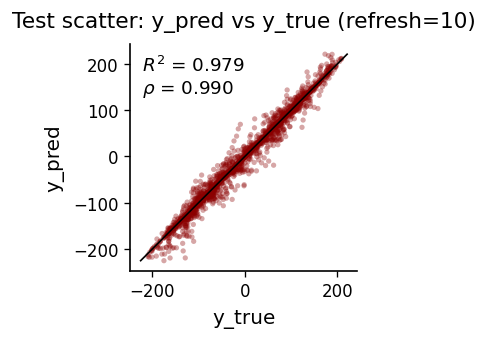

In [12]:
def plot_scatter(y_true, y_pred, refresh, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(y_true, y_pred, c=color_alt, alpha=0.35, s=10, edgecolors="none")
    vmin, vmax = min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))
    ax.plot([vmin, vmax], [vmin, vmax], color=color_main, lw=1)
    yt = y_true - np.mean(y_true)
    yp = y_pred - np.mean(y_pred)
    corr = float((yt @ yp) / np.sqrt((yt @ yt) * (yp @ yp) + 1e-12))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / (ss_tot + 1e-12)
    ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\n$\\rho$ = {corr:.3f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round"))
    ax.set_aspect('equal', adjustable='box')
    prettify(ax, title=f"Test scatter: y_pred vs y_true (refresh={refresh})", xlabel="y_true", ylabel="y_pred")
    plt.tight_layout()
    plt.show()

plot_scatter(y[ntr:], yhat_ctrl, REFRESH_EVERY)

/tmp/ipykernel_3516722/165049562.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5)


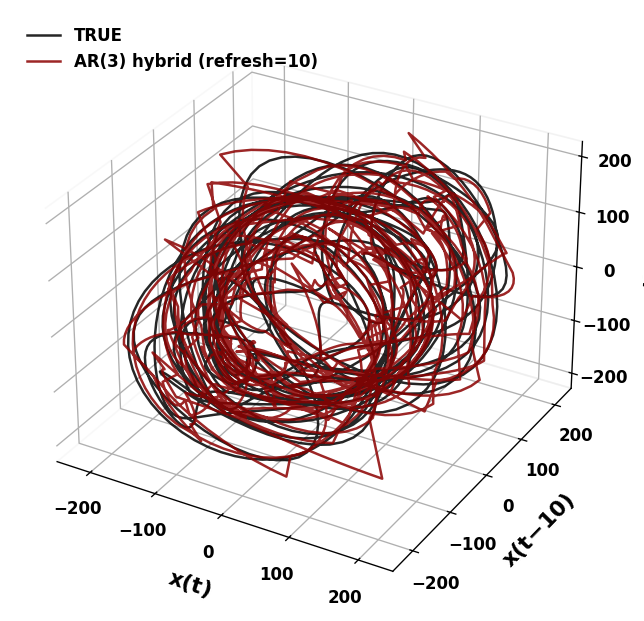

In [13]:
def plot_state_space(X3_true, X3_pred, p, tau, refresh, color_true="black", color_pred="darkred"):
    from matplotlib.ticker import MaxNLocator
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(X3_true[:,0], X3_true[:,1], X3_true[:,2], label="TRUE", color=color_true, alpha=0.85, lw=1.5)
    ax.plot(X3_pred[:,0], X3_pred[:,1], X3_pred[:,2], label=f"AR({p}) hybrid (refresh={refresh})", color=color_pred, alpha=0.85, lw=1.5)

    # Bold axis labels (LaTeX)
    ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
    ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
    ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)

    # Limit tick count to avoid crowding
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(axis='both', pad=4, labelsize=10)

    # Bold tick labels
    for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
        label.set_fontweight('bold')

    # Remove grey background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.legend(frameon=False, loc='upper left', fontsize=11, prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95)
    plt.tight_layout(pad=2.5)
    plt.show()

tau = 10
hy = yhat_ctrl - np.mean(yhat_ctrl)
hy = hy * (np.std(true_test) / (np.std(hy) + 1e-12)) + np.mean(true_test)

X3_true = embed(true_test, 3, tau)
X3_hyb = embed(hy, 3, tau)

plot_state_space(X3_true, X3_hyb, p_use, tau, REFRESH_EVERY)

/tmp/ipykernel_3516722/2864093511.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


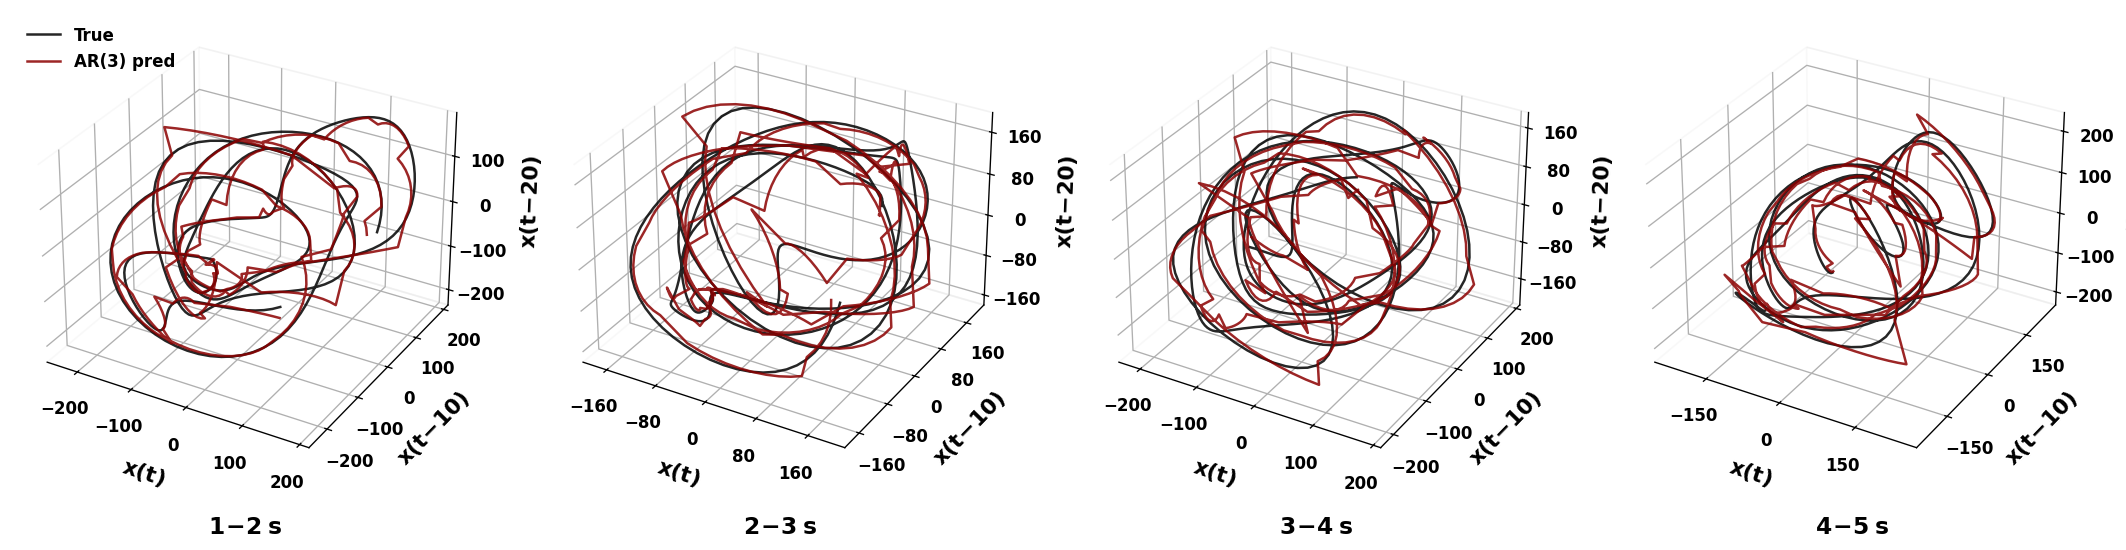

In [14]:
def plot_state_space_windows_comparison(xs, xs_pred, Fs, tau, embed_dim=3, 
                                         windows=[(1, 2), (2, 3), (3, 4), (4, 5)]):
    fig, axes = plt.subplots(1, 4, figsize=(len(windows)*4.5, 5), subplot_kw={'projection': '3d'})
    
    for ax, (t_start, t_end) in zip(axes, windows):
        idx_start = int(t_start * Fs)
        idx_end = int(t_end * Fs)
        
        # True signal
        segment_true = xs[idx_start:idx_end]
        X3_true = embed(segment_true, embed_dim, tau)
        
        # Predicted signal (variance-matched)
        segment_pred = xs_pred[idx_start:idx_end]
        seg_pred_matched = segment_pred - np.mean(segment_pred)
        seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
        seg_pred_matched = seg_pred_matched + np.mean(segment_true)
        X3_pred = embed(seg_pred_matched, embed_dim, tau)
        
        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=f'AR({p_use}) pred')
        
        # Bold axis labels (LaTeX)
        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)
        
        # Limit tick count to avoid crowding (adapts to data range)
        from matplotlib.ticker import MaxNLocator
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis='both', pad=4, labelsize=10)
        
        # Bold tick labels
        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')
        
        # Remove grey background panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        
        # Bold time-window annotation
        ax.text2D(0.5, -0.12, f"$\\mathbf{{{t_start}\\!-\\!{t_end} \\; s}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')
    
    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    # plt.savefig("4.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# Build full prediction for visualization
full_pred = AR.hybrid_predict(xs, w, p_use, start_idx=p_use, n_steps=len(xs)-p_use, refresh_every=REFRESH_EVERY)
xs_pred_full = np.concatenate([xs[:p_use], full_pred])

plot_state_space_windows_comparison(xs, xs_pred_full, Fs, tau)

/tmp/ipykernel_3516722/2806596430.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


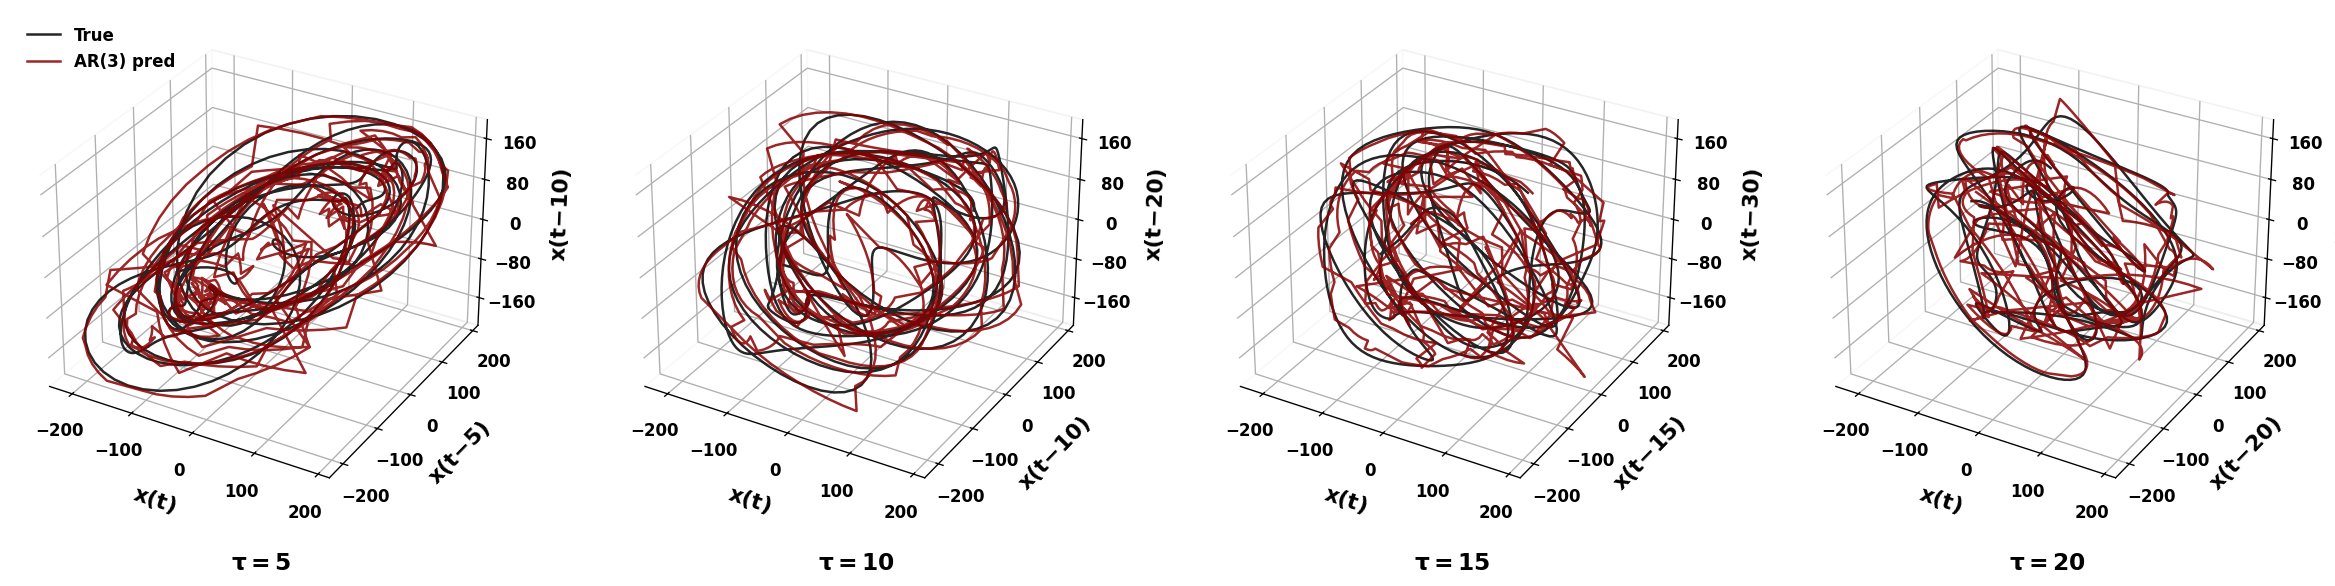

In [15]:
def plot_state_space_tau_sweep(xs, xs_pred, Fs, t_start, t_end, taus=[5, 10, 15, 20], embed_dim=3):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': '3d'})
    
    idx_start = int(t_start * Fs)
    idx_end = int(t_end * Fs)
    segment_true = xs[idx_start:idx_end]
    segment_pred = xs_pred[idx_start:idx_end]
    
    # Variance-match prediction
    seg_pred_matched = segment_pred - np.mean(segment_pred)
    seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
    seg_pred_matched = seg_pred_matched + np.mean(segment_true)
    
    for ax, tau_val in zip(axes, taus):
        X3_true = embed(segment_true, embed_dim, tau_val)
        X3_pred = embed(seg_pred_matched, embed_dim, tau_val)
        
        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=f'AR({p_use}) pred')
        
        # Bold axis labels (LaTeX)
        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau_val})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau_val})}}$", labelpad=8, fontsize=13)
        
        # Limit tick count to avoid crowding
        from matplotlib.ticker import MaxNLocator
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis='both', pad=4, labelsize=10)
        
        # Bold tick labels
        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')
        
        # Remove grey background panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        
        # Bold caption
        ax.text2D(0.5, -0.12, f"$\\mathbf{{\\tau = {tau_val}}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')
    
    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.savefig("5.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# Use valid time window within 5 second signal
plot_state_space_tau_sweep(xs, xs_pred_full, Fs, t_start=2, t_end=4)

Full data shape: (4, 10841760)


/tmp/ipykernel_3516722/702895028.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


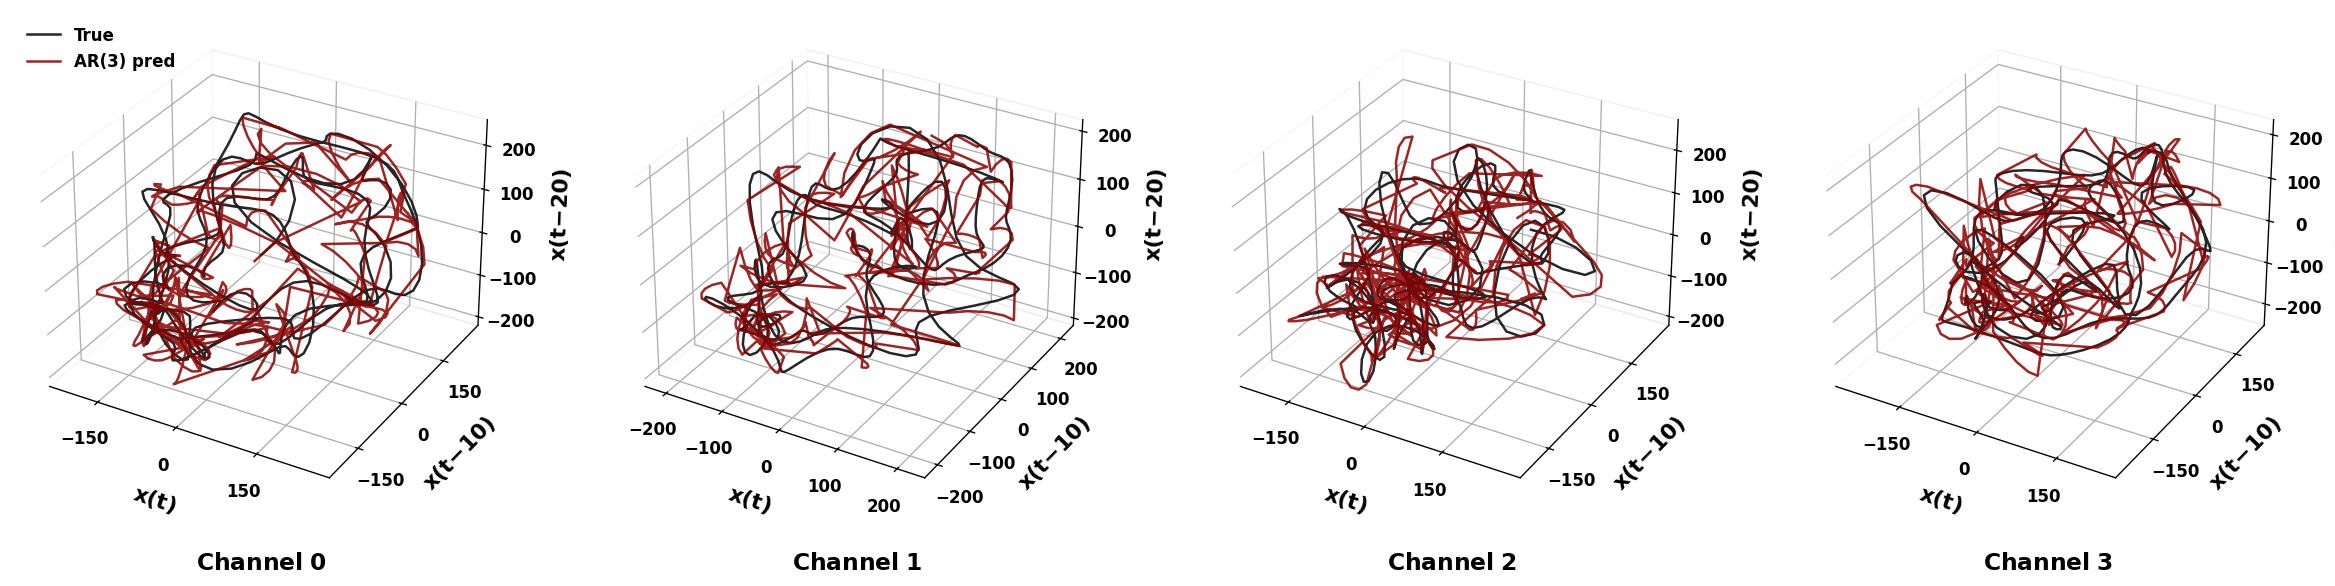

In [16]:
def sweep_channels_plot(raw_data, channels, time_windows, taus, fs_orig,
                        p=3, train_frac=0.9, refresh_every=5,
                        bandpass_low=1.0, bandpass_high=50.0, 
                        fband=(1, 80), env_lp_hz=3.0, embed_dim=3,
                        target_Fs=500):
    """
    Process multiple channels from mouse data and plot state space comparison.
    """
    n = len(channels)
    fig, axes = plt.subplots(1, n, figsize=(n*5, 5), subplot_kw={'projection': '3d'})
    if n == 1:
        axes = [axes]
    
    # Convert to (samples, channels) format
    LFP = raw_data.T
    
    for ax, chan, (t_start, t_end), tau_val in zip(axes, channels, time_windows, taus):
        # Create time window indices
        time_window = np.arange(int(t_end * fs_orig))
        
        # Process signal
        xs_ch, _, Fs_ch = process_signal(LFP, chan, fs_orig, time_window,
                                          bandpass_low=bandpass_low, bandpass_high=bandpass_high,
                                          fband=fband, env_lp_hz=env_lp_hz,
                                          target_Fs=target_Fs)
        
        # Fit AR model
        ar_res = fit_ar_model(xs_ch, Fs_ch, p=p, train_frac=train_frac, refresh_every=refresh_every)
        w_ch, xs_pred_ch = ar_res['w'], ar_res['xs_pred_full']
        
        # Extract window
        idx_start, idx_end = int(t_start * Fs_ch), int(t_end * Fs_ch)
        segment_true = xs_ch[idx_start:idx_end]
        segment_pred = xs_pred_ch[idx_start:idx_end]
        
        # Variance-match prediction
        seg_pred_matched = segment_pred - np.mean(segment_pred)
        seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
        seg_pred_matched = seg_pred_matched + np.mean(segment_true)
        
        # Embed
        X3_true = embed(segment_true, embed_dim, tau_val)
        X3_pred = embed(seg_pred_matched, embed_dim, tau_val)
        
        # Plot
        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=f'AR({p}) pred')
        
        # Bold axis labels (LaTeX)
        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau_val})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau_val})}}$", labelpad=8, fontsize=13)
        
        # Limit tick count to avoid crowding
        from matplotlib.ticker import MaxNLocator
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis='both', pad=4, labelsize=10)
        
        # Bold tick labels
        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')
        
        # Remove grey background panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        
        # Bold caption
        ax.text2D(0.5, -0.12, f"$\\mathbf{{Channel \\; {chan}}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')
    
    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.savefig("6.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# Load full raw data for multi-channel sweep
raw_data_full = np.load(filename)
print(f"Full data shape: {raw_data_full.shape}")

# Sweep across channels (using valid channels and time windows)
sweep_channels_plot(
    raw_data_full, 
    channels=[0, 1, 2, 3],
    time_windows=[(5, 6), (6, 7), (8, 9), (10, 11)],
    taus=[10, 10, 10, 10],
    fs_orig=fs_original,
    target_Fs=500
)

# Torus fits

According to elbow method, the p is 3. we fix that for now

for the data only:
1. We need to measure torus fit and catch the r^2, and the parameters of the fit, and the beti number
2. We need to sweep these params :
    1. over different slides of a fixed time window. continious slide
    2. over differnt size of the time window. start with 0.1 then increase it by 0.1 increments. start from the first 0.1 seconds, then the first 0.2 seconds, and so on until we reach the end of the data.

In [ ]:
def fit_torus(X):
    """
    Fit a torus directly in the lag-embedding coordinate frame.
    X is Nx3: columns are [x(t), x(t-τ), x(t-2τ)].

    Major circle lies in the (x(t), x(t-τ)) plane.
    R = major radius, r = minor radius, R² = torus surface fit quality.
    """
    Xc  = X - X.mean(axis=0)

    rho = np.sqrt(Xc[:, 0]**2 + Xc[:, 1]**2)   # distance from lag axis (3rd axis)
    R   = float(np.mean(rho))                    # major radius

    d   = np.sqrt((rho - R)**2 + Xc[:, 2]**2)   # distance from major circle
    r   = float(np.mean(d))                      # minor radius

    SS_res = float(np.sum((d - r)**2))
    SS_tot = float(np.sum((d - np.mean(d))**2))
    r2     = 1.0 - SS_res / (SS_tot + 1e-12)

    return dict(R=R, r=r, r2=r2, aspect=R / (r + 1e-12))

    # residuals = d - r
    # SS_res    = float(np.sum(residuals**2))
    # SS_tot    = float(np.sum(Xc**2))
    # r2        = 1.0 - SS_res / (SS_tot + 1e-12)

    # return dict(R=R, r=r, r2=r2, aspect=R / (r + 1e-12))
    


def betti_numbers(X, maxdim=2, thresh_pct=0.3, max_pts=500):
    """
    Betti numbers β0, β1, β2 via ripser persistent homology.
    Returns tuple (β0, β1, β2) or None if ripser is not installed.

    Features with persistence > thresh_pct * max_persistence are counted.
    For a torus the expected values are β0=1, β1=2, β2=1.
    """
    Xs   = X[np.random.choice(len(X), max_pts, replace=False)] if len(X) > max_pts else X
    dgms = ripser.ripser(Xs, maxdim=maxdim)['dgms']

    bettis = []
    for k, dgm in enumerate(dgms):
        if len(dgm) == 0:
            bettis.append(0)
            continue
        finite   = np.isfinite(dgm[:, 1])
        pers_fin = (dgm[finite, 1] - dgm[finite, 0]) if np.any(finite) else np.array([])
        thresh   = thresh_pct * (pers_fin.max() if len(pers_fin) > 0 else 1.0)
        count = int(np.sum(~finite)) if k == 0 else int(np.sum(pers_fin > thresh))
        bettis.append(count)

    return tuple(bettis)


def torus_metrics(seg, tau=10, embed_dim=3):
    """Embed signal segment then compute torus fit + Betti numbers."""
    X    = embed(seg, embed_dim, tau)
    fit  = fit_torus(X)
    beta = betti_numbers(X)
    return dict(R=fit['R'], r=fit['r'], r2=fit['r2'], aspect=fit['aspect'], beta=beta)


In [18]:
def _sweep_window_metrics(xs, start, stop, tau, embed_dim):
    seg = xs[start:stop]
    return torus_metrics(seg, tau, embed_dim)


def sliding_window_sweep(xs, Fs, window_s=1.0, step_s=0.1, tau=10, embed_dim=3,
                         show_progress=True, max_workers=None):
    """
    Slide a fixed-size window over xs.
    Returns list of dicts: t_center, R, r, r2, aspect, beta.
    """
    win = int(window_s * Fs)
    step = int(step_s * Fs)
    min_len = (embed_dim - 1) * tau + 5
    starts = np.arange(0, max(len(xs) - win + 1, 0), step, dtype=int)
    valid_starts = [start for start in starts if win > min_len]

    if len(valid_starts) == 0:
        return []

    worker_count = max_workers or min(32, os.cpu_count() or 1)
    results = []
    with ThreadPoolExecutor(max_workers=worker_count) as executor:
        metrics_iter = executor.map(
            lambda start: _sweep_window_metrics(xs, start, start + win, tau, embed_dim),
            valid_starts,
        )
        iterator = tqdm(metrics_iter, total=len(valid_starts), desc="Sliding windows", leave=False) if show_progress else metrics_iter
        for start, metrics in zip(valid_starts, iterator):
            results.append(dict(
                t_center=(start + win / 2) / Fs,
                **{key: metrics[key] for key in ('R', 'r', 'r2', 'aspect', 'beta')}
            ))
    return results


def growing_window_sweep(xs, Fs, step_s=0.1, tau=10, embed_dim=3,
                         show_progress=True, max_workers=None):
    """
    Grow window from step_s to the full signal in step_s increments.
    Returns list of dicts: duration, R, r, r2, aspect, beta.
    """
    step = int(step_s * Fs)
    min_len = (embed_dim - 1) * tau + 5
    windows = np.arange(step, len(xs) + 1, step, dtype=int)
    valid_windows = [win for win in windows if win > min_len]

    if len(valid_windows) == 0:
        return []

    worker_count = max_workers or min(32, os.cpu_count() or 1)
    results = []
    with ThreadPoolExecutor(max_workers=worker_count) as executor:
        metrics_iter = executor.map(
            lambda win: _sweep_window_metrics(xs, 0, win, tau, embed_dim),
            valid_windows,
        )
        iterator = tqdm(metrics_iter, total=len(valid_windows), desc="Growing windows", leave=False) if show_progress else metrics_iter
        for win, metrics in zip(valid_windows, iterator):
            results.append(dict(
                duration=win / Fs,
                **{key: metrics[key] for key in ('R', 'r', 'r2', 'aspect', 'beta')}
            ))
    return results

In [19]:
TAU       = 10
EMBED_DIM = 3

# Single torus fit on the full processed clip
X_full   = embed(xs, EMBED_DIM, TAU)
fit_full = fit_torus(X_full)
beta_full = betti_numbers(X_full)

print(f"Torus fit — full clip ({len(xs)/Fs:.1f} s, {len(X_full)} embedded points)")
print(f"  R  (major radius) = {fit_full['R']:.4f}")
print(f"  r  (minor radius) = {fit_full['r']:.4f}")
print(f"  R² (torus fit)    = {fit_full['r2']:.4f}")
print(f"  R/r (aspect)      = {fit_full['aspect']:.3f}")


print(f"  Betti numbers     = β0={beta_full[0]}, β1={beta_full[1]}, β2={beta_full[2]}")
print(f"  (torus expected:   β0=1, β1=2, β2=1)")


Torus fit — full clip (5.0 s, 2480 embedded points)
  R  (major radius) = 125.3983
  r  (minor radius) = 99.3948
  R² (torus fit)    = 0.9303
  R/r (aspect)      = 1.262
  Betti numbers     = β0=1, β1=13, β2=11
  (torus expected:   β0=1, β1=2, β2=1)


In [ ]:
WINDOW_S = 1.0   # fixed window for sliding sweep (seconds)
STEP_S   = 0.1   # step / increment (seconds)
N_WORKERS = min(16, os.cpu_count() or 1)

slide_results = sliding_window_sweep(
    xs, Fs, window_s=WINDOW_S, step_s=STEP_S, tau=TAU,
    max_workers=N_WORKERS,
)


Sliding windows:   0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
grow_results = growing_window_sweep(
    xs, Fs, step_s=STEP_S, tau=TAU,
    max_workers=N_WORKERS,
)

print(f"Sliding sweep  ({WINDOW_S} s window, {STEP_S} s step): {len(slide_results)} windows")
print(f"Growing sweep  ({STEP_S} s step, up to {len(xs)/Fs:.1f} s):  {len(grow_results)} windows")
print(f"Parallel workers used: {N_WORKERS}")

In [ ]:
def plot_torus_sweep(results, x_key, x_label, title_prefix,
                    color_main="black", color_alt="darkred"):
    xs_plot  = [r[x_key]  for r in results]
    r2_vals  = [r['r2']   for r in results]
    R_vals   = [r['R']    for r in results]
    r_vals   = [r['r']    for r in results]
    asp_vals = [r['aspect'] for r in results]
    has_beta = results[0]['beta'] is not None

    n_rows = 4 if has_beta else 3
    fig, axes = plt.subplots(n_rows, 1, figsize=(7, n_rows * 2.5), sharex=True)

    axes[0].plot(xs_plot, r2_vals, color=color_main, lw=1.5)
    prettify(axes[0], title=f"{title_prefix} — Torus R²", xlabel="", ylabel="R²")

    axes[1].plot(xs_plot, R_vals, color=color_main, lw=1.5, label="R (major)")
    axes[1].plot(xs_plot, r_vals, color=color_alt,  lw=1.5, label="r (minor)")
    prettify(axes[1], title="Radii", xlabel="", ylabel="Radius", add_legend=True)

    axes[2].plot(xs_plot, asp_vals, color=color_alt, lw=1.5)
    prettify(axes[2], title="Aspect ratio  R / r", xlabel=x_label, ylabel="R / r")

    if has_beta:
        b0 = [r['beta'][0] for r in results]
        b1 = [r['beta'][1] for r in results]
        b2 = [r['beta'][2] for r in results]
        axes[3].step(xs_plot, b0, color='black',    lw=1.2, label="β₀")
        axes[3].step(xs_plot, b1, color=color_alt,  lw=1.2, label="β₁")
        axes[3].step(xs_plot, b2, color='steelblue', lw=1.2, label="β₂")
        prettify(axes[3], title="Betti numbers", xlabel=x_label, ylabel="β", add_legend=True)

    plt.tight_layout()
    plt.show()


# --- Sliding window ---
plot_torus_sweep(slide_results,
                 x_key='t_center', x_label=f'Window centre (s)  [window = {WINDOW_S} s]',
                 title_prefix='Sliding window')


In [ ]:
# --- Growing window ---
plot_torus_sweep(grow_results,
                 x_key='duration', x_label='Window size (s)',
                 title_prefix='Growing window')
